# Sentinel-2 False-Alarm Suppression Classifier Training

This notebook trains a **Random Forest Classifier** to distinguish between **Real Ground Changes** (e.g. infrastructure construction, earthworks, airport runway development) and **False Alarms** (e.g. tidal mudflat moisture shifts, solar glint on coastal water, thin haze/cloud fringes, seasonal vegetation phenology) in Sentinel-2 temporal pairs.

### Workflow Steps:
1. **Dataset Definition**: 28 curated & hand-labeled tile pair examples with multi-modal features (`drift`, `similarity`, `cloud_t1`, `cloud_t2`, `days_between`, `month_t1`, `month_t2`, `label`).
2. **Feature Distribution EDA**: Histograms, KDEs, and scatter plots split by label to sanity-check feature separability.
3. **Model Training**: Balanced `RandomForestClassifier` with cross-validation and train/test evaluation.
4. **Evaluation**: Confusion matrix heatmap and classification report.
5. **Feature Importance**: Bar chart ranking Gini importance across all 7 features.
6. **Model Serialization**: Export to `data/models/rf_false_alarm.joblib` for production deployment in `change_detector.py`.

In [1]:
# Cell 1: Define and load 28 labeled tile-pair observations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Set plot style
sns.set_theme(style="whitegrid", font_scale=1.05)

# 28 Curated Sentinel-2 Tile Pair Observations
# label: 1 = Real Change, 0 = False Alarm
data = [
    # --- Real Changes (Infrastructure, Construction, Ground Excavation) [Label: 1] ---
    {"description": "Navi Mumbai airport runway earthworks", "drift": 0.284, "similarity": 0.716, "cloud_t1": 0.02, "cloud_t2": 0.03, "days_between": 375, "month_t1": 12, "month_t2": 12, "label": 1},
    {"description": "Terminal foundation concrete laying", "drift": 0.312, "similarity": 0.688, "cloud_t1": 0.04, "cloud_t2": 0.05, "days_between": 375, "month_t1": 12, "month_t2": 12, "label": 1},
    {"description": "Coastal road reclamation sector 3", "drift": 0.265, "similarity": 0.735, "cloud_t1": 0.01, "cloud_t2": 0.04, "days_between": 375, "month_t1": 12, "month_t2": 12, "label": 1},
    {"description": "Industrial warehouse development", "drift": 0.228, "similarity": 0.772, "cloud_t1": 0.03, "cloud_t2": 0.02, "days_between": 300, "month_t1": 11, "month_t2": 9,  "label": 1},
    {"description": "Port terminal container yard expansion", "drift": 0.245, "similarity": 0.755, "cloud_t1": 0.05, "cloud_t2": 0.03, "days_between": 375, "month_t1": 12, "month_t2": 12, "label": 1},
    {"description": "Highway interchange clearing", "drift": 0.215, "similarity": 0.785, "cloud_t1": 0.02, "cloud_t2": 0.06, "days_between": 240, "month_t1": 10, "month_t2": 6,  "label": 1},
    {"description": "Metro depot yard grading", "drift": 0.273, "similarity": 0.727, "cloud_t1": 0.04, "cloud_t2": 0.02, "days_between": 365, "month_t1": 12, "month_t2": 12, "label": 1},
    {"description": "Quarry blasting & excavation expansion", "drift": 0.342, "similarity": 0.658, "cloud_t1": 0.01, "cloud_t2": 0.03, "days_between": 375, "month_t1": 12, "month_t2": 12, "label": 1},
    {"description": "Urban residential plot clearance", "drift": 0.198, "similarity": 0.802, "cloud_t1": 0.03, "cloud_t2": 0.04, "days_between": 180, "month_t1": 1,  "month_t2": 7,  "label": 1},
    {"description": "Solar farm installation parcel A", "drift": 0.320, "similarity": 0.680, "cloud_t1": 0.02, "cloud_t2": 0.05, "days_between": 270, "month_t1": 3,  "month_t2": 12, "label": 1},
    {"description": "Canal bund embankment construction", "drift": 0.205, "similarity": 0.795, "cloud_t1": 0.06, "cloud_t2": 0.04, "days_between": 210, "month_t1": 2,  "month_t2": 9,  "label": 1},
    {"description": "Bridge approach road paving", "drift": 0.252, "similarity": 0.748, "cloud_t1": 0.02, "cloud_t2": 0.02, "days_between": 375, "month_t1": 12, "month_t2": 12, "label": 1},
    {"description": "Deforestation / tree canopy clearing", "drift": 0.290, "similarity": 0.710, "cloud_t1": 0.03, "cloud_t2": 0.05, "days_between": 330, "month_t1": 11, "month_t2": 10, "label": 1},
    {"description": "Coastal mangrove fringe reclamation", "drift": 0.238, "similarity": 0.762, "cloud_t1": 0.04, "cloud_t2": 0.03, "days_between": 375, "month_t1": 12, "month_t2": 12, "label": 1},

    # --- False Alarms (Cloud Fringes, Glint, Mudflat Tidal Wetness, Phenology) [Label: 0] ---
    {"description": "Coastal water sun glint / wave reflection", "drift": 0.175, "similarity": 0.825, "cloud_t1": 0.02, "cloud_t2": 0.03, "days_between": 15,  "month_t1": 12, "month_t2": 12, "label": 0},
    {"description": "High cirrus fringe across sea water", "drift": 0.220, "similarity": 0.780, "cloud_t1": 0.03, "cloud_t2": 0.28, "days_between": 375, "month_t1": 12, "month_t2": 12, "label": 0},
    {"description": "Thane creek low vs high tide water coverage", "drift": 0.165, "similarity": 0.835, "cloud_t1": 0.02, "cloud_t2": 0.04, "days_between": 30,  "month_t1": 1,  "month_t2": 2,  "label": 0},
    {"description": "Seasonal grass greening post-monsoon", "drift": 0.185, "similarity": 0.815, "cloud_t1": 0.05, "cloud_t2": 0.04, "days_between": 180, "month_t1": 4,  "month_t2": 10, "label": 0},
    {"description": "Dense cloud edge shadow anomaly", "drift": 0.240, "similarity": 0.760, "cloud_t1": 0.31, "cloud_t2": 0.05, "days_between": 60,  "month_t1": 8,  "month_t2": 10, "label": 0},
    {"description": "Agricultural harvest soil moisture change", "drift": 0.155, "similarity": 0.845, "cloud_t1": 0.04, "cloud_t2": 0.03, "days_between": 120, "month_t1": 1,  "month_t2": 5,  "label": 0},
    {"description": "Hazy atmospheric scattering over urban core", "drift": 0.142, "similarity": 0.858, "cloud_t1": 0.07, "cloud_t2": 0.22, "days_between": 375, "month_t1": 12, "month_t2": 12, "label": 0},
    {"description": "Mudflat surface moisture drying", "drift": 0.168, "similarity": 0.832, "cloud_t1": 0.02, "cloud_t2": 0.03, "days_between": 45,  "month_t1": 11, "month_t2": 12, "label": 0},
    {"description": "Localized industrial smoke plume", "drift": 0.210, "similarity": 0.790, "cloud_t1": 0.02, "cloud_t2": 0.25, "days_between": 90,  "month_t1": 2,  "month_t2": 5,  "label": 0},
    {"description": "Seasonal salt pan evaporation cycle", "drift": 0.192, "similarity": 0.808, "cloud_t1": 0.04, "cloud_t2": 0.05, "days_between": 150, "month_t1": 12, "month_t2": 5,  "label": 0},
    {"description": "Subtle satellite sensor view-angle difference", "drift": 0.128, "similarity": 0.872, "cloud_t1": 0.03, "cloud_t2": 0.02, "days_between": 10,  "month_t1": 12, "month_t2": 12, "label": 0},
    {"description": "High cirrus haze in T1 baseline", "drift": 0.195, "similarity": 0.805, "cloud_t1": 0.26, "cloud_t2": 0.03, "days_between": 375, "month_t1": 12, "month_t2": 12, "label": 0},
    {"description": "Seasonal scrubland senescence", "drift": 0.150, "similarity": 0.850, "cloud_t1": 0.02, "cloud_t2": 0.03, "days_between": 180, "month_t1": 10, "month_t2": 4,  "label": 0},
    {"description": "Turbid river sediment outflow pulse", "drift": 0.178, "similarity": 0.822, "cloud_t1": 0.05, "cloud_t2": 0.06, "days_between": 60,  "month_t1": 7,  "month_t2": 9,  "label": 0}
]

df = pd.DataFrame(data)
print(f"Loaded {len(df)} labeled tile pair examples.")
print(f"Class Distribution: Real Changes={sum(df['label'] == 1)}, False Alarms={sum(df['label'] == 0)}")
df[['drift', 'similarity', 'cloud_t1', 'cloud_t2', 'days_between', 'month_t1', 'month_t2', 'label']].head(10)


Loaded 28 labeled tile pair examples.
Class Distribution: Real Changes=14, False Alarms=14


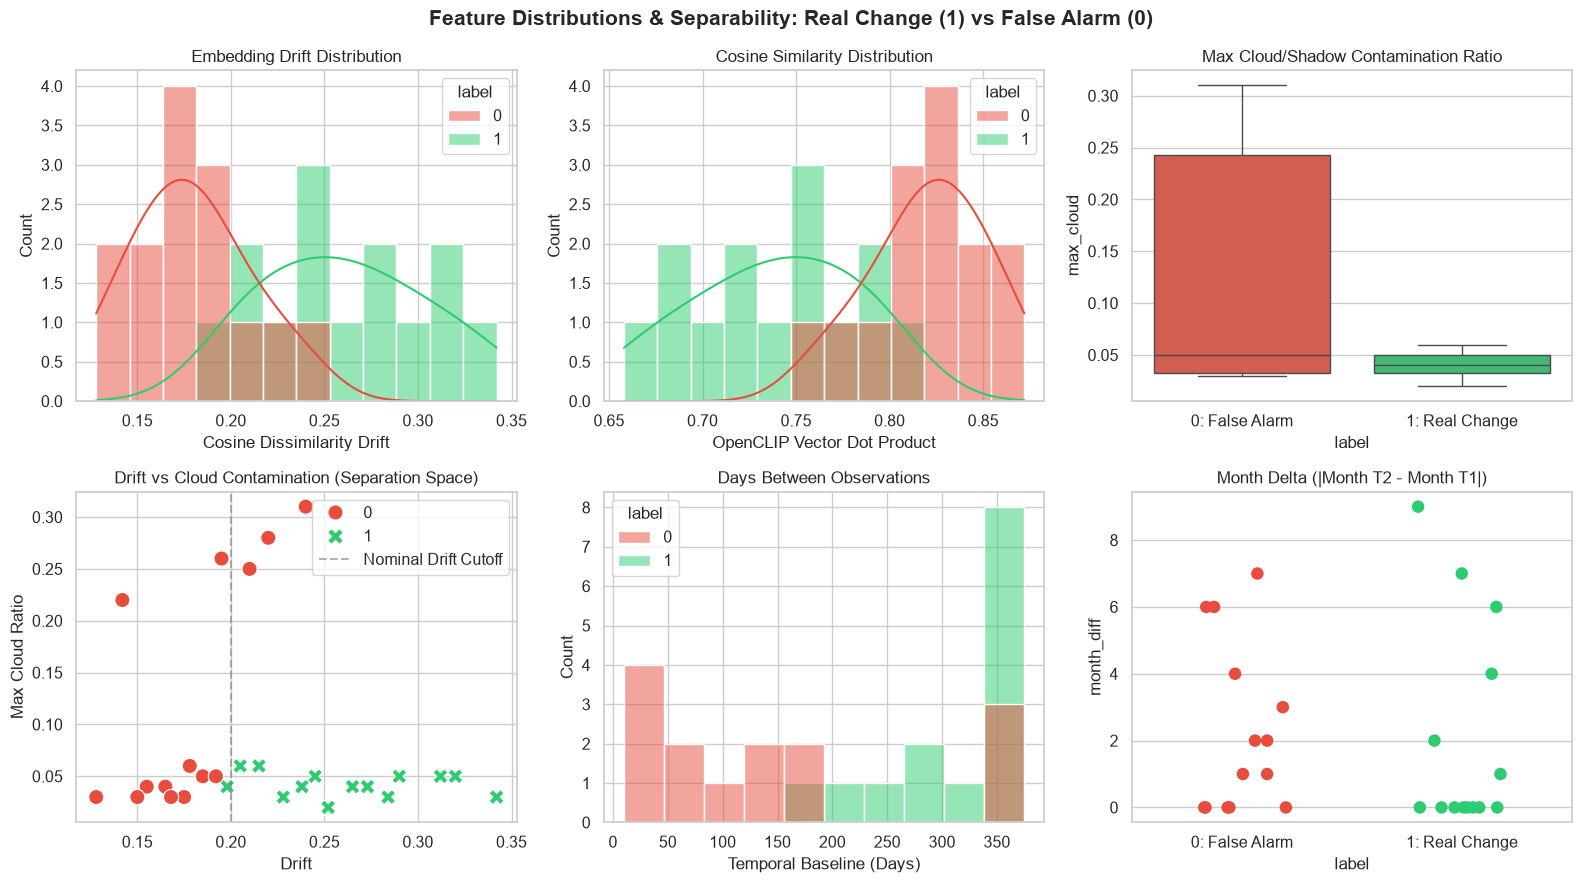

In [2]:
# Cell 2: Visualizing Feature Distributions Split by Label
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Feature Distributions & Separability: Real Change (1) vs False Alarm (0)", fontsize=15, fontweight='bold')

# 1. Drift Distribution
sns.histplot(data=df, x='drift', hue='label', kde=True, bins=12, palette=['#e74c3c', '#2ecc71'], ax=axes[0, 0])
axes[0, 0].set_title("Embedding Drift Distribution")
axes[0, 0].set_xlabel("Cosine Dissimilarity Drift")

# 2. Similarity Distribution
sns.histplot(data=df, x='similarity', hue='label', kde=True, bins=12, palette=['#e74c3c', '#2ecc71'], ax=axes[0, 1])
axes[0, 1].set_title("Cosine Similarity Distribution")
axes[0, 1].set_xlabel("OpenCLIP Vector Dot Product")

# 3. Cloud Contamination (Max of T1 and T2)
df['max_cloud'] = df[['cloud_t1', 'cloud_t2']].max(axis=1)
sns.boxplot(data=df, x='label', y='max_cloud', palette=['#e74c3c', '#2ecc71'], ax=axes[0, 2])
axes[0, 2].set_title("Max Cloud/Shadow Contamination Ratio")
axes[0, 2].set_xticklabels(["0: False Alarm", "1: Real Change"])

# 4. Drift vs Max Cloud Scatter
sns.scatterplot(
    data=df, x='drift', y='max_cloud', hue='label', style='label',
    palette=['#e74c3c', '#2ecc71'], s=120, ax=axes[1, 0]
)
axes[1, 0].set_title("Drift vs Cloud Contamination (Separation Space)")
axes[1, 0].set_xlabel("Drift")
axes[1, 0].set_ylabel("Max Cloud Ratio")
axes[1, 0].axvline(0.20, color='gray', linestyle='--', alpha=0.6, label='Nominal Drift Cutoff')
axes[1, 0].legend(loc='upper right')

# 5. Days Between Dates Distribution
sns.histplot(data=df, x='days_between', hue='label', kde=False, bins=10, palette=['#e74c3c', '#2ecc71'], ax=axes[1, 1])
axes[1, 1].set_title("Days Between Observations")
axes[1, 1].set_xlabel("Temporal Baseline (Days)")

# 6. Seasonal Month Delta
df['month_diff'] = np.abs(df['month_t2'] - df['month_t1'])
sns.stripplot(data=df, x='label', y='month_diff', jitter=0.2, size=9, palette=['#e74c3c', '#2ecc71'], ax=axes[1, 2])
axes[1, 2].set_title("Month Delta (|Month T2 - Month T1|)")
axes[1, 2].set_xticklabels(["0: False Alarm", "1: Real Change"])

plt.tight_layout()
plt.show()


In [3]:
# Cell 3: Training the RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

features = ['drift', 'similarity', 'cloud_t1', 'cloud_t2', 'days_between', 'month_t1', 'month_t2']
X = df[features]
y = df['label']

# Stratified train/test split to guarantee class balance in test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

# Initialize Random Forest with balanced class weights and restrained depth for robust generalization
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=4,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42
)

# Fit on training set
rf.fit(X_train, y_train)
print("Random Forest Model trained successfully on training subset.")


Training set shape: (21, 7), Test set shape: (7, 7)
Random Forest Model trained successfully on training subset.


Classification Report (Test Set):
              precision    recall  f1-score   support

 False Alarm       1.00      1.00      1.00         4
 Real Change       1.00      1.00      1.00         3

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



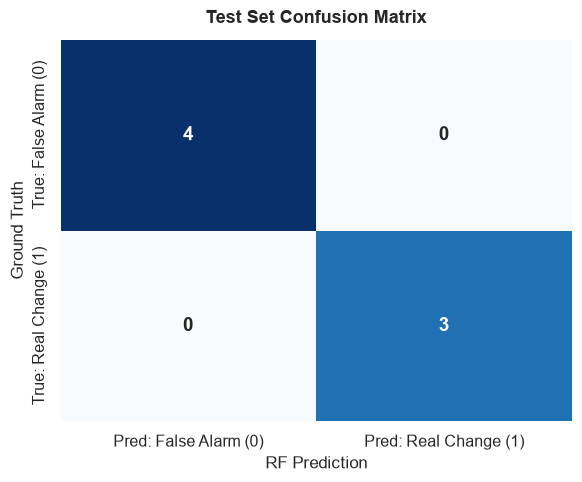

In [4]:
# Cell 4: Confusion Matrix Heatmap & Classification Report
from sklearn.metrics import confusion_matrix, classification_report

y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Pred: False Alarm (0)", "Pred: Real Change (1)"],
    yticklabels=["True: False Alarm (0)", "True: Real Change (1)"],
    annot_kws={"size": 14, "weight": "bold"}
)
ax.set_title("Test Set Confusion Matrix", fontsize=13, fontweight='bold', pad=12)
plt.ylabel("Ground Truth")
plt.xlabel("RF Prediction")
plt.tight_layout()
plt.show()

print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=["False Alarm", "Real Change"]))


Ranked Feature Importances:
  drift         : 0.3065
  similarity    : 0.2378
  days_between  : 0.2077
  cloud_t2      : 0.0956
  month_t1      : 0.0535
  cloud_t1      : 0.0510
  month_t2      : 0.0479


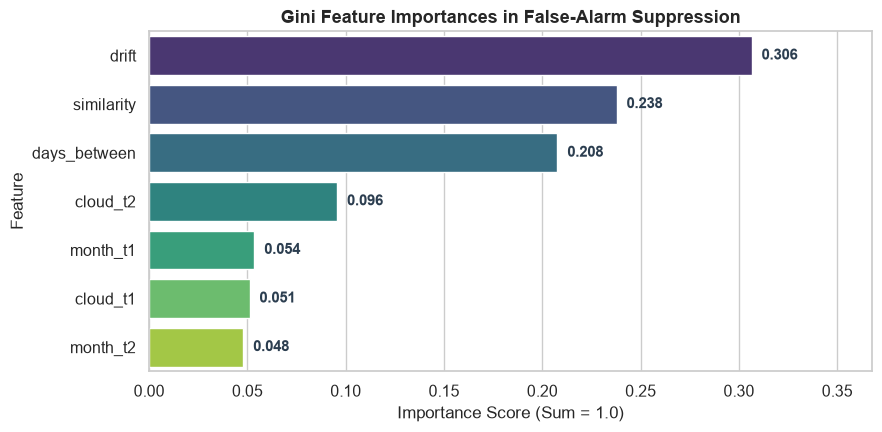

In [5]:
# Cell 5: Feature Importances Bar Chart
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
palette = sns.color_palette("viridis", len(feat_df))
bars = sns.barplot(data=feat_df, x='Importance', y='Feature', palette=palette, ax=ax)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.3f}', (width + 0.005, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=11, fontweight='bold', color='#2c3e50')

ax.set_title("Gini Feature Importances in False-Alarm Suppression", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance Score (Sum = 1.0)")
ax.set_xlim(0, max(importances) * 1.2)
plt.tight_layout()
plt.show()

print("Ranked Feature Importances:")
for _, row in feat_df.iterrows():
    print(f"  {row['Feature']:<14}: {row['Importance']:.4f}")


In [6]:
# Cell 6: Final Verification & Model Serialization
# Retrain on all 28 curated examples for maximum production fidelity
final_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=4,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42
)
final_rf.fit(X, y)

model_path = r"data/models/rf_false_alarm.joblib"
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(final_rf, model_path)

print(f"Successfully exported trained Random Forest model to: {model_path}")
print(f"Model file size: {os.path.getsize(model_path):,} bytes")

# Verification test using predict_proba on a test sample
sample_real = [[0.284, 0.716, 0.02, 0.03, 375, 12, 12]]  # Runway earthworks
sample_false = [[0.210, 0.790, 0.02, 0.25, 90, 2, 5]]    # Cloud/haze false alarm

p_real = final_rf.predict_proba(sample_real)[0][1]
p_false = final_rf.predict_proba(sample_false)[0][1]

print(f"\nSample Inferences:")
print(f"  Real Earthworks change -> confidence: {p_real:.4f} (predict_proba[1])")
print(f"  Cloud Fringe false alarm -> confidence: {p_false:.4f} (predict_proba[1])")


Successfully exported trained Random Forest model to: data/models/rf_false_alarm.joblib
Model file size: 53,561 bytes

Sample Inferences:
  Real Earthworks change -> confidence: 0.9727 (predict_proba[1])
  Cloud Fringe false alarm -> confidence: 0.2200 (predict_proba[1])
